In [15]:
experiment = r".\results\seed45_nB100_fixed_x_dict_items([('max_leaf_nodes', 5)])"

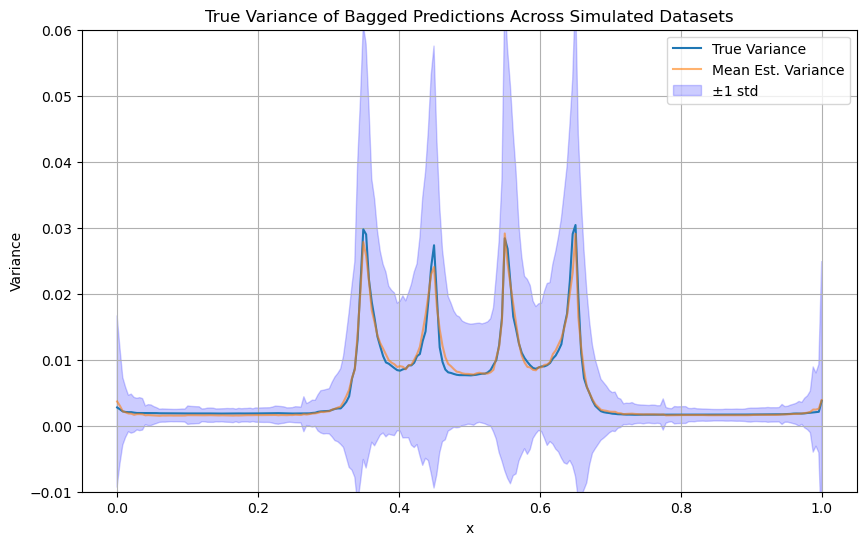

In [20]:
import pandas as pd
from utils import save_results_png, step_function
import matplotlib.pyplot as plt
import numpy as np

df_preds = pd.read_csv(experiment+str('bagged_preds.csv'), sep =';' ) 
df_vars = pd.read_csv(experiment+str('est_vars.csv'), sep =';' )
new_data = df_preds.columns[1:].to_list()

bagged_preds = df_preds[new_data]
est_vars = df_vars[new_data]
new_data = [float(i) for i in new_data]
new_data = np.array(new_data)

save_results_png(new_data=new_data, bagged_preds=bagged_preds,est_vars=est_vars, show_only_plot=True)

In [27]:
neg_vars = est_vars[est_vars<0]

# entferne zeilen und spalten, wo alle werte NaN sind 
neg_vars = neg_vars.dropna(axis=0, how='all')
neg_vars = neg_vars.dropna(axis=1, how='all')

x =  0.35341365461847385
y_true =  0.7


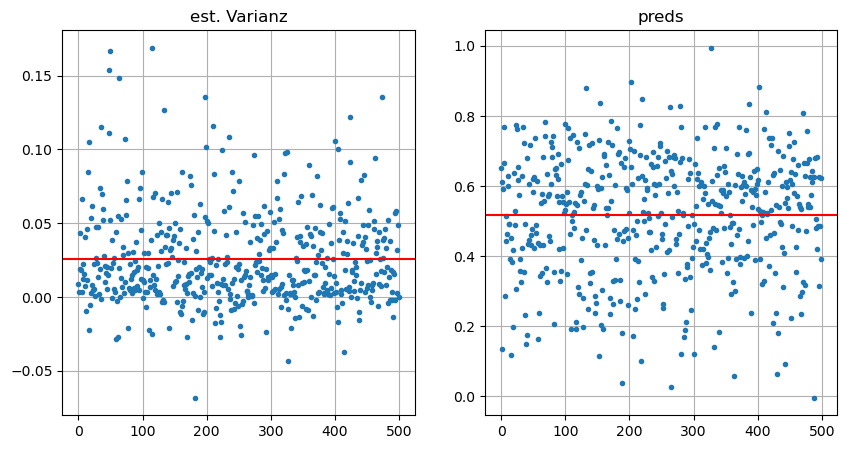

In [26]:
x = 0.355

# finde den Index von new_data, der x am nächsten ist
ind = (np.abs(new_data - x)).argmin()
x = new_data[ind]
y_true = step_function(x)
print('x = ', x)
print('y_true = ', y_true)

# plotte die Varianz und die Vorhersagen für x
vars = est_vars.iloc[:, ind]
preds = bagged_preds.iloc[:, ind] 

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(vars, 'o',markersize=3)  
axs[0].grid()
axs[0].set_title('est. Varianz')
axs[1].plot(preds, 'o',markersize=3)  
mean_preds = np.mean(preds)
axs[1].axhline(y=mean_preds, color='r', linestyle='-', label='Mean Line')
mean_vars = np.mean(vars)
axs[0].axhline(y=mean_vars, color='r', linestyle='-', label='Mean Line')
axs[1].grid()
axs[1].set_title('preds')
plt.show()